In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
# --- BẢNG MASTER ---
products = pd.read_csv('dataset/products.csv')
customers = pd.read_csv('dataset/customers.csv', parse_dates=['signup_date'])
promotions = pd.read_csv('dataset/promotions.csv', parse_dates=['start_date', 'end_date'])
geography = pd.read_csv('dataset/geography.csv')

# --- BẢNG TRANSACTION ---
orders = pd.read_csv('dataset/orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv('dataset/order_items.csv')
payments = pd.read_csv('dataset/payments.csv')
shipments = pd.read_csv('dataset/shipments.csv', parse_dates=['ship_date', 'delivery_date'])
returns = pd.read_csv('dataset/returns.csv', parse_dates=['return_date'])
reviews = pd.read_csv('dataset/reviews.csv', parse_dates=['review_date'])

# --- BẢNG ANALYTICAL ---
sales = pd.read_csv('dataset/sales.csv', parse_dates=['Date'])
# File test và sample thường chỉ cần đọc bình thường
#sales_test = pd.read_csv('dataset/sales_test.csv') 
sample_submission = pd.read_csv('dataset/sample_submission.csv')

# --- BẢNG OPERATIONAL ---
inventory = pd.read_csv('dataset/inventory.csv', parse_dates=['snapshot_date'])
# Giả sử inventory_enhanced có cùng cột ngày với inventory
#inventory_enhanced = pd.read_csv('dataset/inventory_enhanced.csv', parse_dates=['snapshot_date'])
web_traffic = pd.read_csv('dataset/web_traffic.csv', parse_dates=['date'])

C:\Users\Admin\AppData\Local\Temp\ipykernel_17396\1409091705.py:9: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv('dataset/order_items.csv')


C:\Users\Admin\AppData\Local\Temp\ipykernel_17396\3001395120.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = sales.set_index('Date').resample('M')[['Revenue', 'COGS']].sum()


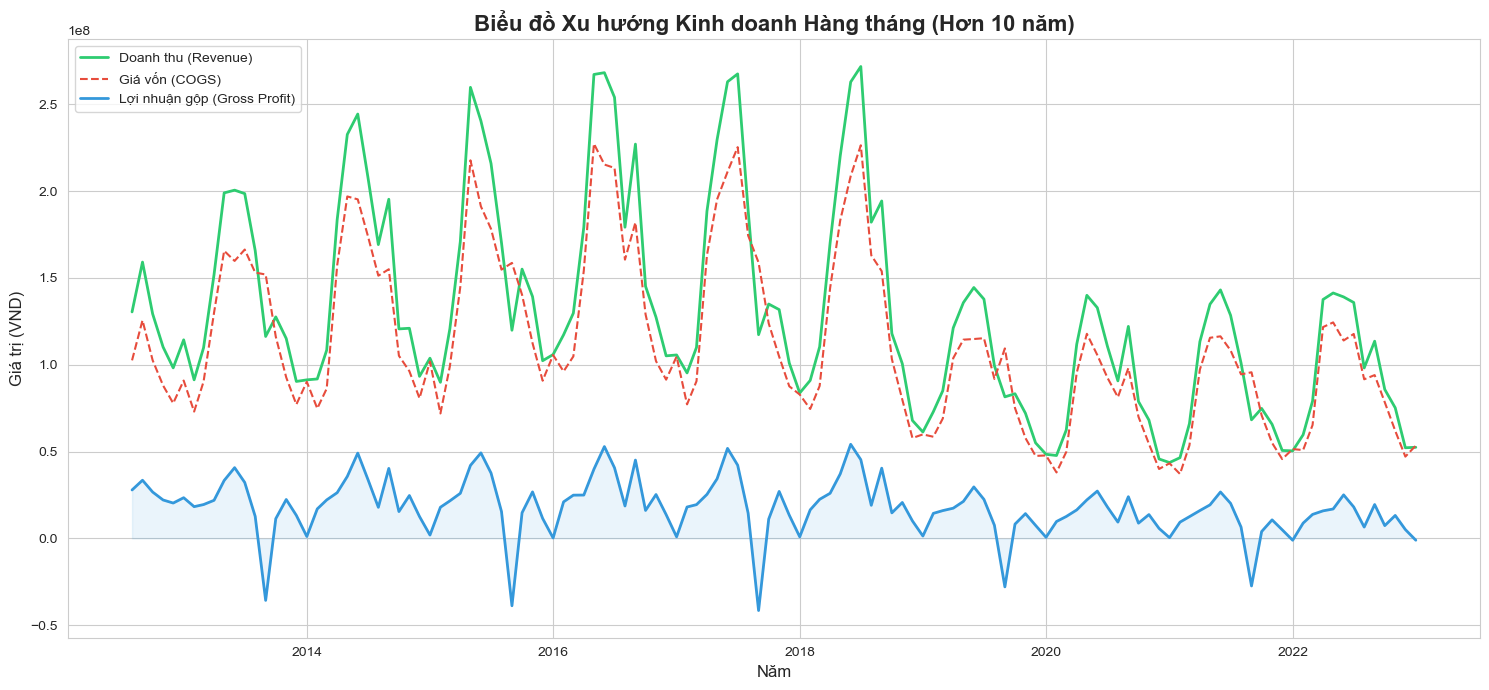

In [3]:
# --- BƯỚC 1: AGGREGATION (Gom nhóm theo tháng) ---
# Tạo bản sao và đặt Date làm index để sử dụng resample
monthly_data = sales.set_index('Date').resample('M')[['Revenue', 'COGS']].sum()

# --- BƯỚC 2: TÍNH TOÁN GROSS PROFIT ---
monthly_data['Gross_Profit'] = monthly_data['Revenue'] - monthly_data['COGS']

# --- BƯỚC 3: TRỰC QUAN HÓA (Multi-line Chart) ---
plt.figure(figsize=(15, 7))
sns.set_style("whitegrid")

# Vẽ các đường chỉ số
plt.plot(monthly_data.index, monthly_data['Revenue'], label='Doanh thu (Revenue)', color='#2ecc71', linewidth=2)
plt.plot(monthly_data.index, monthly_data['COGS'], label='Giá vốn (COGS)', color='#e74c3c', linewidth=1.5, linestyle='--')
plt.plot(monthly_data.index, monthly_data['Gross_Profit'], label='Lợi nhuận gộp (Gross Profit)', color='#3498db', linewidth=2)

# Thêm vùng đổ bóng cho Lợi nhuận gộp để làm nổi bật
plt.fill_between(monthly_data.index, monthly_data['Gross_Profit'], color='#3498db', alpha=0.1)

# Định dạng biểu đồ
plt.title('Biểu đồ Xu hướng Kinh doanh Hàng tháng (Hơn 10 năm)', fontsize=16, fontweight='bold')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Giá trị (VND)', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()

plt.show()

## Trend Doanh thu của công ty
- Doanh thu có tính mùa vụ mạnh khi thay đổi mạnh theo tháng
- Sự hiện diện của Covid-19 ảnh hưởng xấu rõ ràng lên doanh thu của công ty
- Tháng 9 mỗi 2 năm (từ 2013) đều có doanh thu âm lớn, điều này chỉ giảm khi Covid-19 xảy ra

In [4]:
order_items

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,1138.22,0.0,NaN,NaN
1,2,609,7,10166.25,0.0,NaN,NaN
2,3,396,3,11220.33,0.0,NaN,NaN
3,4,635,5,10639.25,0.0,NaN,NaN
4,6,1935,1,1597.84,0.0,NaN,NaN
...,...,...,...,...,...,...,...
714664,834372,690,8,4473.92,0.0,NaN,NaN
714665,834377,1995,7,5250.79,0.0,NaN,NaN
714666,834387,2331,8,7389.06,0.0,NaN,NaN
714667,834392,1115,5,4767.33,0.0,NaN,NaN


In [5]:
products

,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.633158,11371.919278
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,15753.717299,8573.172954
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,15766.334536,14063.570406
...,...,...,...,...,...,...,...,...
2407,1260,VietMode MP-28,Casual,Activewear,S,red,4603.340000,2553.933032
2408,1261,VietMode MP-29,Casual,Activewear,M,black,5983.876433,4653.660702
2409,1262,VietMode MP-30,Casual,Activewear,L,orange,5983.876433,5684.682611
2410,1263,VietMode MP-31,Casual,Activewear,XL,blue,5984.370000,5685.151500


In [6]:
master_df = order_items.merge(products, on='product_id', how='left')
master_df['Total_Revenue'] = master_df['price'] * master_df['quantity'] - master_df['discount_amount']
master_df['Total_COGS'] = master_df['cogs'] * master_df['quantity']

# Gom nhóm theo Category và Segment
cat_seg_revenue = master_df.groupby(['category', 'segment'])['Total_Revenue'].sum().reset_index()

# --- BƯỚC 2: VẼ BIỂU ĐỒ (Donut + Stacked Bar) ---
fig = make_subplots(rows=1, cols=2, 
                    specs=[[{'type':'domain'}, {'type':'xy'}]],
                    subplot_titles=('Tỷ trọng theo Danh mục (Donut)', 'Doanh thu theo Phân khúc (Stacked Bar)'))

# 1. Donut Chart (Tổng quan theo Category)
cat_revenue = cat_seg_revenue.groupby('category')['Total_Revenue'].sum().reset_index()
fig.add_trace(go.Pie(labels=cat_revenue['category'], 
                     values=cat_revenue['Total_Revenue'], 
                     hole=.4, name="Category"), row=1, col=1)

# 2. Stacked Bar Chart (Chi tiết Segment trong từng Category)
for segment in cat_seg_revenue['segment'].unique():
    segment_data = cat_seg_revenue[cat_seg_revenue['segment'] == segment]
    fig.add_trace(go.Bar(x=segment_data['category'], 
                         y=segment_data['Total_Revenue'], 
                         name=segment), row=1, col=2)

# Định dạng layout
fig.update_layout(
    title_text="Phân tích Cơ cấu Doanh thu theo Danh mục và Phân khúc",
    barmode='stack',
    showlegend=True,
    height=600
)
fig.show()

In [7]:

master_df['Gross_Profit'] = master_df['Total_Revenue'] - master_df['Total_COGS']

# Aggregation theo Category
comparison = master_df.groupby('category')[['Total_Revenue', 'Total_COGS', 'Gross_Profit']].sum().reset_index()

# Vẽ biểu đồ Grouped Bar để thấy sự hao hụt qua từng bước
fig = px.bar(comparison, x='category', y=['Total_Revenue', 'Total_COGS', 'Gross_Profit'],
             barmode='group',
             title='So sánh các cấp độ Doanh thu và Lợi nhuận theo Danh mục')
fig.show()

## Categories nào mang lại nhiều doanh thu nhất
- SP dòng Streetwear chiếm đến 80.3% doanh thu trong đó thì segment Balance, Everyday, Performance chiếm chủ yếu
- SP dòng Outdoor cũng chiếm tới 14.9% doanh thu và chủ yếu phụ thuộc vào segment Activewear
- Gross profit của Streetwear cao gấp 5 lần các category khác dẫn đến Streetwear là nguồn thu chính của công ty

In [8]:
# --- BƯỚC 1: JOIN DỮ LIỆU ---
# Kết nối customers và orders để lấy thông tin Demographic + Status
df_merged = orders.merge(customers[['customer_id', 'gender', 'age_group', 'acquisition_channel']], 
                         on='customer_id', how='inner')

# --- BƯỚC 2: TỔNG HỢP SỐ LƯỢNG THEO TRẠNG THÁI ---
# Tạo bảng đếm số đơn hàng theo Segment và Status
def plot_status_distribution(df, segment_col):
    # Đếm số lượng đơn hàng
    status_counts = df.groupby([segment_col, 'order_status']).size().reset_index(name='order_count')
    
    # Tính toán tỷ lệ % để so sánh công bằng giữa các nhóm có quy mô khác nhau
    total_by_segment = status_counts.groupby(segment_col)['order_count'].transform('sum')
    status_counts['percentage'] = (status_counts['order_count'] / total_by_segment * 100).round(2)
    
    # Vẽ biểu đồ Stacked Bar
    fig = px.bar(status_counts, 
                 x=segment_col, 
                 y='order_count', 
                 color='order_status',
                 text='percentage', # Hiển thị số % trên thanh
                 title=f'Phân bổ Trạng thái đơn hàng theo {segment_col}',
                 labels={'order_count': 'Số lượng đơn hàng', 'status': 'Trạng thái'},
                 category_orders={"status": ['delivered', 'paid', 'shipped', 'created', 'cancelled', 'returned']},
                 color_discrete_map={
                     'delivered': '#27ae60', # Xanh lá (Thành công)
                     'returned': '#e74c3c',  # Đỏ (Thất bại)
                     'cancelled': '#95a5a6', # Xám (Hủy)
                     'paid': '#2ecc71',
                     'shipped': '#f1c40f',
                     'created': '#3498db'
                 })
    
    fig.update_traces(texttemplate='%{text}%', textposition='inside')
    fig.update_layout(barmode='stack')
    fig.show()

# --- BƯỚC 3: HIỂN THỊ ---
# Bạn có thể gọi hàm cho từng chiều muốn xem
plot_status_distribution(df_merged, 'age_group')
plot_status_distribution(df_merged, 'acquisition_channel')

## Phân phối của các nhóm tuổi và kênh
- Các kênh cũng như nhóm tuổi gần như ko có tác động trực tiếp lên phân phối của trạng thái đơn hàng
- Tuy nhiên có thể thấy số lượng đơn hàng được phân bổ rõ ràng qua các nhóm tuổi, kênh 

In [9]:
orders['order_status'].unique()

array(['delivered', 'returned', 'shipped', 'cancelled', 'paid', 'created'],
      dtype=object)

In [10]:
customers

,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
0,1,15201,Hai Phong,2021-12-30,Female,35-44,social_media
1,2,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign
2,3,15201,Hai Phong,2018-07-24,Female,18-24,organic_search
3,4,15201,Hai Phong,2017-11-29,Male,35-44,referral
4,5,15201,Hai Phong,2022-09-23,Male,55+,organic_search
...,...,...,...,...,...,...,...
121925,157556,59936,Vung Tau,2016-03-03,Female,18-24,direct
121926,157557,59936,Vung Tau,2021-05-11,Female,45-54,social_media
121927,157558,59936,Vung Tau,2017-02-27,Female,25-34,referral
121928,157561,59937,Buon Ma Thuot,2018-10-15,Non-binary,45-54,paid_search


In [11]:
# 1. Build a revenue table per order
order_items['line_total'] = order_items['quantity'] * order_items['unit_price'] - order_items['discount_amount']
order_revenue = order_items.groupby('order_id')['line_total'].sum().reset_index()
# 2. Join with orders to get customer_id
order_revenue = order_revenue.merge(orders[['order_id', 'customer_id']], on='order_id')
# 3. Join with customers to get demographics
customer_revenue = order_revenue.merge(customers[['customer_id', 'gender', 'age_group', 'acquisition_channel']], on='customer_id')
# 4. Now you can aggregate by any demographic dimension
by_gender = customer_revenue.groupby('gender')['line_total'].agg(['sum', 'mean', 'count'])
by_age = customer_revenue.groupby('age_group')['line_total'].agg(['sum', 'mean', 'count'])
by_channel = customer_revenue.groupby('acquisition_channel')['line_total'].agg(['sum', 'mean', 'count'])

In [12]:
fig = px.treemap(by_channel.reset_index(), 
                 path=['acquisition_channel'], 
                 values='sum', 
                 color='mean',
                 title='Hiệu quả Kênh tiếp cận: Tổng doanh thu vs. AOV',
                 color_continuous_scale='RdYlGn')
fig.show()

In [13]:
def plot_dual_axis(df_agg, dimension_name):
    # Reset index để đưa các cột dimension ra ngoài
    df = df_agg.reset_index()
    
    # Tạo subplot với 2 trục Y
    fig = make_subplots(specs=[[{"secondary_y": True}]])

    # 1. Vẽ cột (Bar) cho Tổng doanh thu (Sum)
    fig.add_trace(
        go.Bar(x=df[dimension_name], y=df['sum'], 
               name="Tổng Doanh Thu", 
               marker_color='#3498db',
               opacity=0.7),
        secondary_y=False,
    )

    # 2. Vẽ đường (Line) cho Giá trị trung bình đơn (Mean/AOV)
    fig.add_trace(
        go.Scatter(x=df[dimension_name], y=df['mean'], 
                   name="Giá trị Đơn trung bình (AOV)",
                   mode='lines+markers+text',
                   text=df['mean'].round(0),
                   textposition="top center",
                   line=dict(color='#e74c3c', width=3)),
        secondary_y=True,
    )

    # Định dạng Layout
    fig.update_layout(
        title_text=f"Phân tích Doanh thu và AOV theo {dimension_name}",
        hovermode="x unified",
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )

    # Đặt tên cho các trục
    fig.update_yaxes(title_text="<b>Tổng Doanh Thu</b> (VND)", secondary_y=False)
    fig.update_yaxes(title_text="<b>Giá trị Đơn (AOV)</b> (VND)", secondary_y=True)

    fig.show()

# --- Chạy biểu đồ cho từng khối bạn đã Group ---
plot_dual_axis(by_age, 'age_group')
plot_dual_axis(by_channel, 'acquisition_channel')
plot_dual_axis(by_gender, 'gender')

In [14]:
# Join orders → geography to get region
orders_geo = orders.merge(geography[['zip', 'region', 'city']], on='zip')

# Join with order revenue
regional = order_revenue.merge(orders_geo[['order_id', 'region', 'city']], on='order_id')


In [16]:
city_coords = {
    # Nhóm bạn đã có
    'Ha Noi': (21.0285, 105.8542), 'Hanoi': (21.0285, 105.8542),
    'Ho Chi Minh': (10.8231, 106.6297), 'Ho Chi Minh City': (10.8231, 106.6297),
    'Hai Phong': (20.8449, 106.6881), 'Da Nang': (16.0544, 108.2022),
    'Can Tho': (10.0452, 105.7469), 'Bac Giang': (21.2731, 106.1946),
    'Viet Tri': (21.3225, 105.4019), 'Phu Ly': (20.5458, 105.9120),
    'Cam Pha': (21.0167, 107.3000), 'Bac Ninh': (21.1861, 106.0763),
    'Thai Nguyen': (21.5942, 105.8482), 'Hue': (16.4637, 107.5909),
    'Nha Trang': (12.2388, 109.1967), 'Quy Nhon': (13.7765, 109.2237),
    'Buon Ma Thuot': (12.6680, 108.0378), 'Da Lat': (11.9465, 108.4419),
    'Vinh': (18.6796, 105.6813), 'Nam Dinh': (20.4388, 106.1621),
    'Thanh Hoa': (19.8067, 105.7852), 'Bien Hoa': (10.9574, 106.8426),
    'Vung Tau': (10.3460, 107.0843), 'Long Xuyen': (10.3860, 105.4350),
    'Rach Gia': (10.0125, 105.0808), 'My Tho': (10.3600, 106.3600),
    'Thai Binh': (20.4500, 106.3400), 'Ha Long': (20.9517, 107.0808),

    # --- CÁC THÀNH PHỐ BỔ SUNG ---
    'Bac Lieu': (9.2941, 105.7278),
    'Ben Tre': (10.2395, 106.3759),
    'Ca Mau': (9.1769, 105.1524),
    'Dong Hoi': (17.4761, 106.5983),
    'Hoi An': (15.8801, 108.3380),
    'Kon Tum': (14.3497, 108.0003),
    'Lao Cai': (22.4856, 103.9707),
    'Ninh Binh': (20.2506, 105.9745),
    'Phan Rang-Thap Cham': (11.5644, 108.9914),
    'Phan Thiet': (10.9250, 108.1046),
    'Pleiku': (13.9781, 108.0069),
    'Quang Ngai': (15.1205, 108.8048),
    'Soc Trang': (9.6033, 105.9742),
    'Son Tay': (21.1350, 105.5030),
    'Tam Ky': (15.5654, 108.4812),
    'Tra Vinh': (9.9348, 106.3335),
    'Tuy Hoa': (13.0882, 109.3009),
    'Uong Bi': (21.0311, 106.7725),
    'Vinh Long': (10.2533, 105.9617)
}

In [17]:
city_stats = regional.groupby('city').agg(
    total_revenue=('line_total', 'sum'),
    order_count=('order_id', 'count')
).reset_index()
# Tính Doanh thu trung bình mỗi đơn (AOV) để làm màu sắc cho bong bóng
city_stats['aov'] = (city_stats['total_revenue'] / city_stats['order_count']).round(2)

city_stats['lat'] = city_stats['city'].map(lambda c: city_coords.get(c, (None, None))[0])
city_stats['lon'] = city_stats['city'].map(lambda c: city_coords.get(c, (None, None))[1])
# Now use scatter_geo with lat/lon
fig = px.scatter_geo(
    city_stats.dropna(subset=['lat', 'lon']),
    lat='lat',
    lon='lon',
    color='total_revenue',
    size='aov',
    hover_name='city',
    scope='asia',
    title='Phân cụm Doanh thu theo Thành phố',
    projection='natural earth',
    center={'lat': 16, 'lon': 107},  # Center on Vietnam
)
fig.update_layout(height=600)
fig.update_geos(
    lataxis_range=[8, 24],   # Vietnam's latitude range
    lonaxis_range=[102, 110] # Vietnam's longitude range
)
fig.show()